# Healthcare Provider Fraud Detection — Model Training & Comparison

Three models on `mv_provider_features` (5,410 providers, 9.35% fraud-flagged):
- Logistic Regression (`class_weight='balanced'` and SMOTE variant)
- Random Forest (`class_weight='balanced'`)
- XGBoost (`scale_pos_weight`)

Plus a **falsifiable hypothesis test**: do the Day-6 patient-risk features add lift to fraud detection?

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

load_dotenv('../../.env')
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)
sns.set_style('whitegrid')
RANDOM_SEED = 42

df = pd.read_sql('SELECT * FROM mv_provider_features;', engine)
print(f'Loaded {len(df):,} providers, {df["label"].sum()} fraud-flagged ({df["label"].mean()*100:.2f}%)')

Loaded 5,410 providers, 506 fraud-flagged (9.35%)


In [2]:
# Postgres NUMERIC -> Decimal in pandas; cast to float64 for sklearn
for c in df.columns:
    if c not in ('provider_id', 'label'):
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')

print('Missing values per column (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

numeric_cols = [c for c in df.columns if c not in ('provider_id', 'label')]
for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())

print(f'\nRemaining missing after fill: {df.isna().sum().sum()}')

Missing values per column (top 10):
coefficient_of_variation    240
stddev_claim_amount         240
avg_diagnoses_per_claim       5
max_diagnoses_per_claim       5
active_days                   0
claims_per_patient            0
total_claims                  0
unique_patients               0
provider_id                   0
label                         0
dtype: int64

Remaining missing after fill: 0


In [3]:
feature_cols = [c for c in df.columns if c not in ('provider_id', 'label')]
X = df[feature_cols]
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print(f'Train: {len(X_train):,} providers ({y_train.sum()} fraud, {y_train.mean()*100:.2f}%)')
print(f'Test:  {len(X_test):,} providers ({y_test.sum()} fraud, {y_test.mean()*100:.2f}%)')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),     columns=feature_cols, index=X_test.index)

Train: 4,328 providers (405 fraud, 9.36%)
Test:  1,082 providers (101 fraud, 9.33%)


## Model 1 — Logistic Regression (class_weight='balanced')

In [4]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Non-Fraud', 'Fraud']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_lr):.4f}')

cm = confusion_matrix(y_test, y_pred_lr)
print(f'\nConfusion Matrix:')
print(f'             Predicted Non / Fraud')
print(f'Actual Non:  {cm[0,0]:>6} / {cm[0,1]:>6}')
print(f'Actual Frd:  {cm[1,0]:>6} / {cm[1,1]:>6}')

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.86      0.92       981
       Fraud       0.40      0.90      0.56       101

    accuracy                           0.87      1082
   macro avg       0.70      0.88      0.74      1082
weighted avg       0.93      0.87      0.89      1082

AUC-ROC:           0.9573
Average Precision: 0.7542

Confusion Matrix:
             Predicted Non / Fraud
Actual Non:     847 /    134
Actual Frd:      10 /     91


## Model 1B — Logistic Regression + SMOTE oversampling

In [5]:
smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE: {len(X_train_smote):,} train samples ({y_train_smote.sum()} fraud, {y_train_smote.mean()*100:.1f}%)')

lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_smote, target_names=['Non-Fraud', 'Fraud']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_lr_smote):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_lr_smote):.4f}')

After SMOTE: 7,846 train samples (3923 fraud, 50.0%)

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.86      0.92       981
       Fraud       0.40      0.90      0.56       101

    accuracy                           0.87      1082
   macro avg       0.70      0.88      0.74      1082
weighted avg       0.93      0.87      0.89      1082

AUC-ROC:           0.9570
Average Precision: 0.7576


## Model 2 — Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Non-Fraud', 'Fraud']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_rf):.4f}')

rf_importance = pd.DataFrame({
    'feature': feature_cols, 'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print('\nTop 10 RF features:')
print(rf_importance.head(10).to_string(index=False))

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.93      0.95       981
       Fraud       0.54      0.78      0.64       101

    accuracy                           0.92      1082
   macro avg       0.76      0.86      0.80      1082
weighted avg       0.94      0.92      0.92      1082

AUC-ROC:           0.9538
Average Precision: 0.7342

Top 10 RF features:
                    feature  importance
           total_reimbursed    0.191124
claims_with_9plus_diagnoses    0.149318
           max_claim_amount    0.094322
           inpatient_claims    0.080098
        stddev_claim_amount    0.059144
    max_diagnoses_per_claim    0.048587
            inpatient_ratio    0.042731
                active_days    0.039284
           avg_claim_amount    0.030734
            unique_patients    0.029074


## Model 3 — XGBoost

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Fraud', 'Fraud']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_xgb):.4f}')

xgb_importance = pd.DataFrame({
    'feature': feature_cols, 'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print('\nTop 10 XGBoost features:')
print(xgb_importance.head(10).to_string(index=False))

scale_pos_weight: 9.69



Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.96      0.95      0.96       981
       Fraud       0.57      0.65      0.61       101

    accuracy                           0.92      1082
   macro avg       0.77      0.80      0.78      1082
weighted avg       0.93      0.92      0.92      1082

AUC-ROC:           0.9404
Average Precision: 0.7122

Top 10 XGBoost features:
                      feature  importance
             total_reimbursed    0.462993
                 median_claim    0.031904
           claims_per_patient    0.031533
              unique_patients    0.030995
          stddev_claim_amount    0.029653
              inpatient_ratio    0.029559
      max_diagnoses_per_claim    0.027360
       pct_high_risk_patients    0.026357
             avg_claim_amount    0.026279
distinct_operating_physicians    0.025592


## Model comparison + ROC curves

MODEL COMPARISON:
        Model  AUC-ROC  Avg Precision  Recall (fraud)  Precision (fraud)  F1 (fraud)
LR (balanced)   0.9573         0.7542          0.9010             0.4044      0.5583
   LR (SMOTE)   0.9570         0.7576          0.9010             0.4027      0.5566
Random Forest   0.9538         0.7342          0.7822             0.5374      0.6371
      XGBoost   0.9404         0.7122          0.6535             0.5690      0.6083


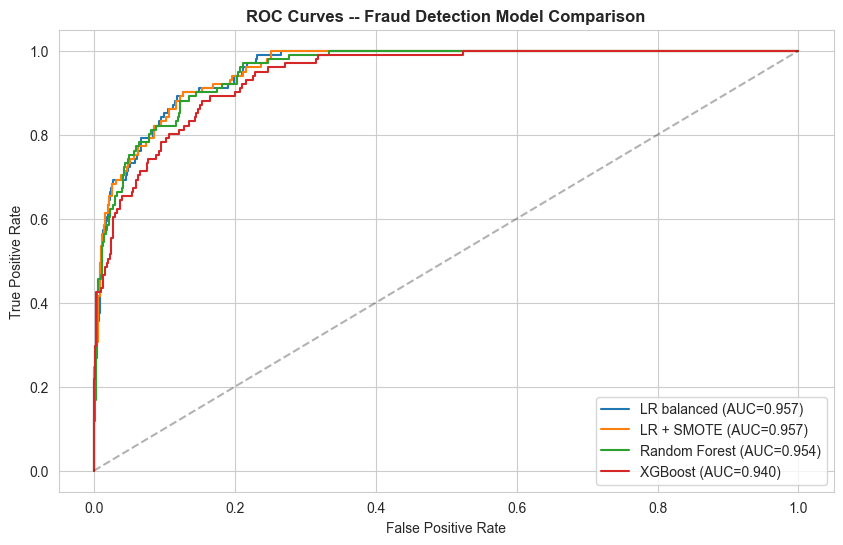

In [8]:
def report_dict(y_true, y_pred):
    return classification_report(y_true, y_pred, output_dict=True)

results = pd.DataFrame({
    'Model': ['LR (balanced)', 'LR (SMOTE)', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_lr_smote),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
    ],
    'Avg Precision': [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_lr_smote),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb),
    ],
    'Recall (fraud)': [
        report_dict(y_test, y_pred_lr)['1']['recall'],
        report_dict(y_test, y_pred_lr_smote)['1']['recall'],
        report_dict(y_test, y_pred_rf)['1']['recall'],
        report_dict(y_test, y_pred_xgb)['1']['recall'],
    ],
    'Precision (fraud)': [
        report_dict(y_test, y_pred_lr)['1']['precision'],
        report_dict(y_test, y_pred_lr_smote)['1']['precision'],
        report_dict(y_test, y_pred_rf)['1']['precision'],
        report_dict(y_test, y_pred_xgb)['1']['precision'],
    ],
    'F1 (fraud)': [
        report_dict(y_test, y_pred_lr)['1']['f1-score'],
        report_dict(y_test, y_pred_lr_smote)['1']['f1-score'],
        report_dict(y_test, y_pred_rf)['1']['f1-score'],
        report_dict(y_test, y_pred_xgb)['1']['f1-score'],
    ],
}).round(4)

print('MODEL COMPARISON:')
print(results.to_string(index=False))

plt.figure(figsize=(10, 6))
for name, proba in [
    ('LR balanced',  y_proba_lr),
    ('LR + SMOTE',   y_proba_lr_smote),
    ('Random Forest', y_proba_rf),
    ('XGBoost',      y_proba_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- Fraud Detection Model Comparison', fontweight='bold')
plt.legend()
plt.savefig('../reports/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Falsifiable hypothesis — do Day 6 risk features add lift?

In [9]:
risk_features = ['avg_patient_risk_score', 'pct_high_risk_patients']
features_without_risk = [f for f in feature_cols if f not in risk_features]

X_train_norisk = X_train[features_without_risk]
X_test_norisk  = X_test[features_without_risk]

xgb_norisk = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1
)
xgb_norisk.fit(X_train_norisk, y_train)
y_proba_norisk = xgb_norisk.predict_proba(X_test_norisk)[:, 1]

auc_with    = roc_auc_score(y_test, y_proba_xgb)
auc_without = roc_auc_score(y_test, y_proba_norisk)
lift = auc_with - auc_without

print(f'AUC with risk features:    {auc_with:.4f}')
print(f'AUC without risk features: {auc_without:.4f}')
print(f'Lift from risk features:   {lift:+.4f}')
if lift > 0.005:
    print('\nVerdict: HYPOTHESIS CONFIRMED -- risk features add measurable lift')
elif lift > 0:
    print('\nVerdict: marginal lift -- risk features help slightly but not decisively')
else:
    print('\nVerdict: HYPOTHESIS REJECTED -- risk features do not improve fraud detection')
    print('         Day 6 risk model captures different signal than fraud detection needs')

AUC with risk features:    0.9404
AUC without risk features: 0.9431
Lift from risk features:   -0.0027

Verdict: HYPOTHESIS REJECTED -- risk features do not improve fraud detection
         Day 6 risk model captures different signal than fraud detection needs


## SHAP analysis on the best model

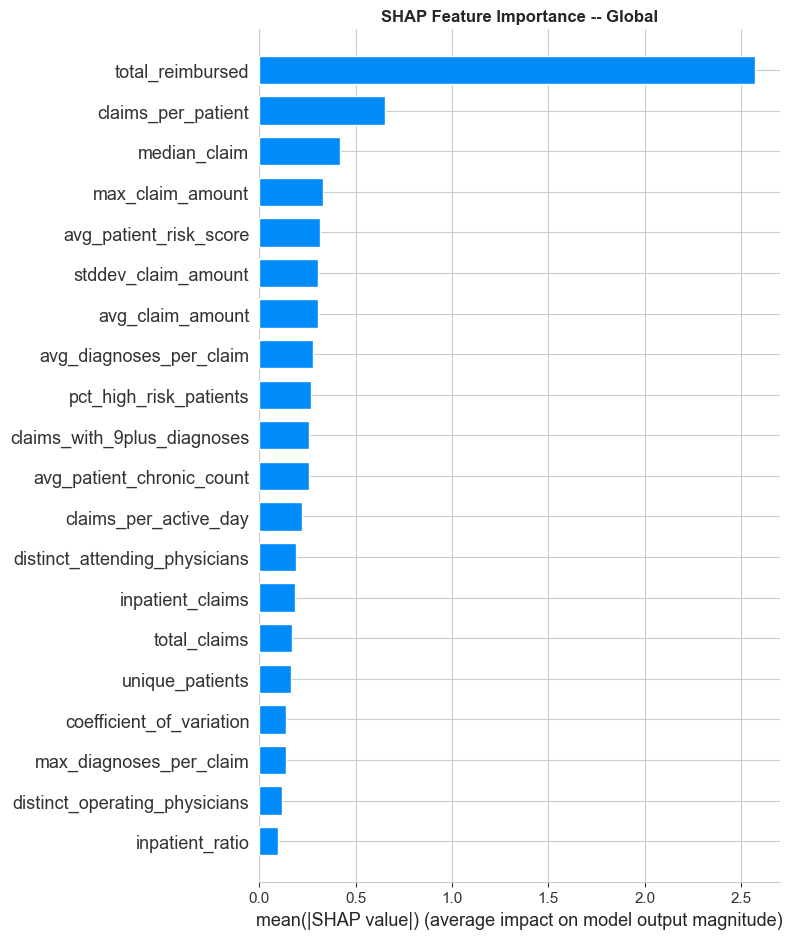

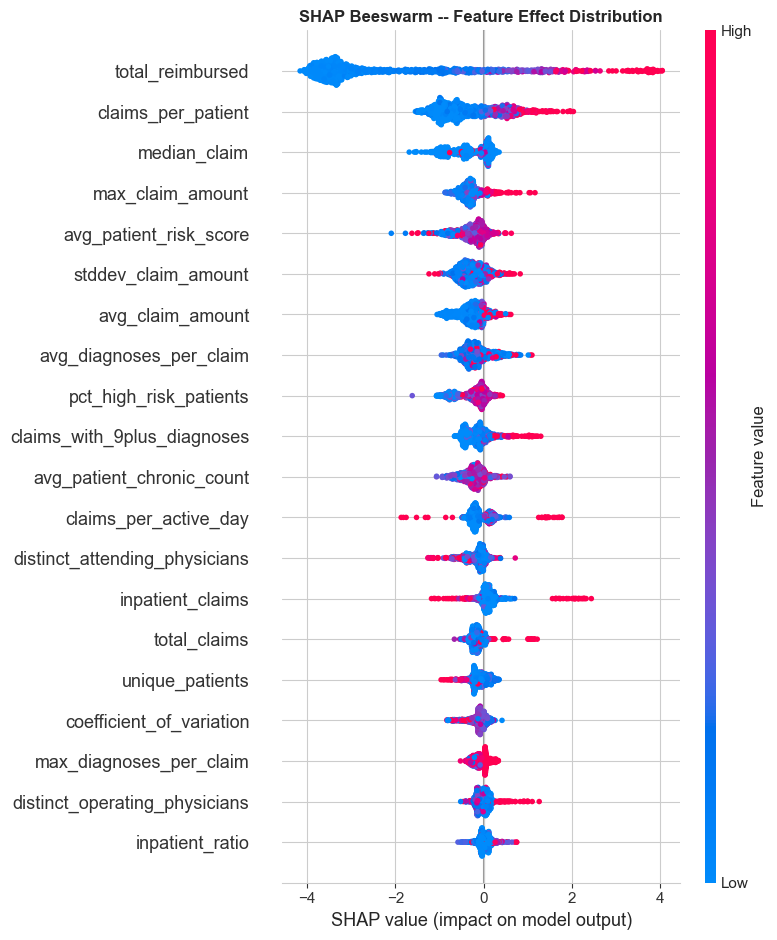

Top 10 features by mean absolute SHAP value:
                    feature  mean_abs_shap
           total_reimbursed       2.572237
         claims_per_patient       0.654180
               median_claim       0.417698
           max_claim_amount       0.330476
     avg_patient_risk_score       0.315302
        stddev_claim_amount       0.305877
           avg_claim_amount       0.303466
    avg_diagnoses_per_claim       0.280304
     pct_high_risk_patients       0.271536
claims_with_9plus_diagnoses       0.258362


In [10]:
import shap

best_model = xgb_model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance -- Global', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm -- Feature Effect Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
print('Top 10 features by mean absolute SHAP value:')
print(shap_importance.head(10).to_string(index=False))

## Persist the best model

In [11]:
from datetime import datetime

rep = report_dict(y_test, y_pred_xgb)
artifact = {
    'model': best_model,
    'feature_cols': feature_cols,
    'training_date': datetime.now().isoformat(),
    'metrics': {
        'auc_roc':         float(roc_auc_score(y_test, y_proba_xgb)),
        'avg_precision':   float(average_precision_score(y_test, y_proba_xgb)),
        'recall_fraud':    float(rep['1']['recall']),
        'precision_fraud': float(rep['1']['precision']),
        'f1_fraud':        float(rep['1']['f1-score']),
        'risk_feature_lift': float(lift),
    },
    'training_set_size': len(X_train),
    'test_set_size': len(X_test),
    'class_balance': float(y_train.mean()),
    'random_seed': RANDOM_SEED,
}
joblib.dump(artifact, '../models/xgb_fraud_detector_v1.joblib')
print('Saved ml/models/xgb_fraud_detector_v1.joblib')
print('Metrics:')
for k, v in artifact['metrics'].items():
    print(f'  {k:20s} {v:.4f}')

Saved ml/models/xgb_fraud_detector_v1.joblib
Metrics:
  auc_roc              0.9404
  avg_precision        0.7122
  recall_fraud         0.6535
  precision_fraud      0.5690
  f1_fraud             0.6083
  risk_feature_lift    -0.0027
